Modifica lo script della lezione per rendere la rete più 'profonda'. Inserisce un terzo layer Conv2d da 64 filtri dopo il seconodo MaxPooling del Flatten.
Osserva come cambia il numero di parametri del model.summary() e scrivi una breve riflessione su cosa accade alla dimensione spaziale (Altezza x Larghezza) prima che i dati arrivino allo strato Dense.

Epoch 1/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 27s 25ms/step - accuracy: 0.9427 - loss: 0.1871
Epoch 2/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 24s 26ms/step - accuracy: 0.9843 - loss: 0.0515
Epoch 3/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 23s 25ms/step - accuracy: 0.9887 - loss: 0.0371


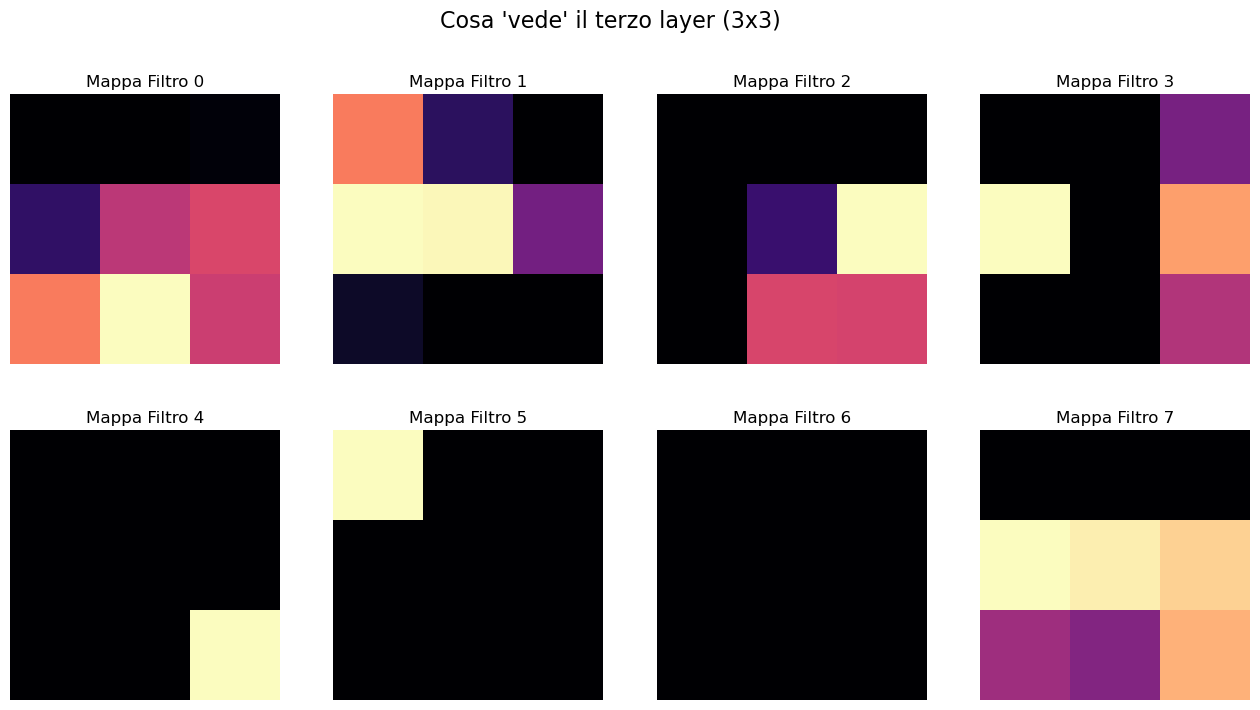

1

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input
import matplotlib.pyplot as plt
import numpy as np

# --- 1. PREPARAZIONE DATI ---
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

# Normalizzazione e Reshape (N, 28, 28, 1)
train_images = train_images.reshape((-1, 28, 28, 1)).astype('float32') / 255.0
test_images = test_images.reshape((-1, 28, 28, 1)).astype('float32') / 255.0

# --- 2. ARCHITETTURA CON API FUNZIONALE ---
def build_model():
    inputs = Input(shape=(28, 28, 1), name="Input_Layer")
    
    # Primo blocco: 32 filtri 3x3
    # Calcolo: ((3*3*1)+1)*32 = 320 parametri
    x = layers.Conv2D(32, (3, 3), activation='relu', name='Conv1')(inputs)
    x = layers.MaxPooling2D((2, 2), name='Pool1')(x)
    
    # Secondo blocco: 64 filtri 3x3
    # Calcolo: ((3*3*32)+1)*64 = 18.496 parametri
    x = layers.Conv2D(64, (3, 3), activation='relu', name='Conv2')(x)
    x = layers.MaxPooling2D((2, 2), name='Pool2')(x)
    
    # Terzo blocco: 64 filtri 3x3
    # Calcolo: ((3*3*64)+1)*64 = 110.592 parametri
    x = layers.Conv2D(64, (3, 3), activation='relu', name='Conv3')(x)
    #x = layers.MaxPooling2D((2, 2), name='Pool3')(x)

    # Testa del modello
    x = layers.Flatten()(x) #permette di convertire le matrici in arrays monodimensionali
    x = layers.Dense(64, activation='relu')(x)
    outputs = layers.Dense(10, activation='softmax')(x)
    
    return models.Model(inputs=inputs, outputs=outputs, name="MNIST_Functional_2025")

model = build_model()

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Training
model.fit(train_images, train_labels, epochs=3, batch_size=64)

# --- 3. ESTRAZIONE DELLE ATTIVAZIONI (Feature Maps) ---

# Prendiamo un'immagine di esempio, # numero 7
img = test_images[0:1] 

# Creiamo il modello di visualizzazione usando i puntatori definiti nel grafo
# Ora model.input è garantito esistere perché il modello è Funzionale
activation_model = models.Model(inputs=model.input, 
                                outputs=model.get_layer('Conv3').output)

# Otteniamo le mappe (forma: 1, 26, 26, 32)
activations = activation_model.predict(img, verbose=0)

# --- 4. VISUALIZZAZIONE ---
plt.figure(figsize=(16, 8))
for i in range(8): # Visualizziamo i primi 8 canali
    plt.subplot(2, 4, i+1)
    plt.imshow(activations[0, :, :, i], cmap='magma')
    plt.axis('off')
    plt.title(f"Mappa Filtro {i}")

plt.suptitle("Cosa 'vede' il terzo layer (3x3)", fontsize=16)
plt.show()
1